# Intelligent Customer Churn Prediction & Retention Optimization System

**Week 3: Statistical Analysis and Hypothesis Testing in Python**

Internship: Virtual Data Science with Python Apprentice Internship

Tools: Python, Pandas, NumPy, SciPy, Matplotlib, Seaborn

Dataset: IBM Telco Customer Churn Dataset

Objective

This week focuses on applying statistical analysis and hypothesis testing to the customer churn dataset. The objective is to formulate clear and testable hypotheses and use appropriate statistical methods to determine whether observed differences and relationships in customer churn data are statistically significant.

The analysis will use statistical tests, p-values, confidence intervals, and supporting visualizations to evaluate the hypotheses and interpret the results. The findings will then be translated into meaningful business insights and customer-retention recommendations.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Preparation

### Dataset Selection

The dataset selected for this project is the IBM Telco Customer Churn dataset.

The dataset contains customer-level information related to demographics,
telecommunication services, account information, billing details, tenure,
and customer churn status.

This dataset was selected because customer churn is a realistic business
problem and the dataset contains both numerical and categorical variables.
It is therefore suitable for data cleaning, exploratory analysis,
statistical analysis, and machine learning in the later stages of this
five-week project.

### Dataset Source

IBM GitHub Repository:
https://github.com/IBM/telco-customer-churn-on-icp4d

The dataset will be acquired directly from the publicly available IBM
repository.

In [4]:
# Load the IBM Telco Customer Churn dataset

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (7043, 21)


In [35]:
# Prepare the dataset for Week 3 analysis

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("Dataset prepared successfully!")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())

Dataset prepared successfully!
Shape: (7043, 21)
Missing values: 0


In [6]:
# Clean TotalCharges, as done in Week 1

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("TotalCharges cleaned successfully!")
print("Missing values in TotalCharges:", df['TotalCharges'].isnull().sum())

TotalCharges cleaned successfully!
Missing values in TotalCharges: 0


In [7]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [8]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Check for missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
Series([], dtype: int64)


In [12]:
# Missing-value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Columns with missing values:")
print(missing_percentage[missing_percentage > 0])

Columns with missing values:
Series([], dtype: float64)


In [13]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [14]:
# Check for duplicate customer IDs
duplicate_customer_ids = df["customerID"].duplicated().sum()

print("Duplicate customer IDs:", duplicate_customer_ids)

Duplicate customer IDs: 0


In [15]:
# Inspect unique values that may cause TotalCharges to be non-numeric
print(df["TotalCharges"].unique()[:20])

[  29.85 1889.5   108.15 1840.75  151.65  820.5  1949.4   301.9  3046.05
 3487.95  587.45  326.8  5681.1  5036.3  2686.05 7895.15 1022.95 7382.25
  528.35 1862.9 ]


In [16]:
# Find blank values in TotalCharges
blank_total_charges = df["TotalCharges"].astype(str).str.strip().eq("").sum()

print("Blank TotalCharges values:", blank_total_charges)

Blank TotalCharges values: 0


In [17]:
# Display rows where TotalCharges is blank
df[df["TotalCharges"].astype(str).str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [18]:
# Display unique values for categorical columns
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


customerID:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender:
['Female' 'Male']

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn:
['No' 'Yes']


In [19]:
# Summary of numerical variables
df.select_dtypes(include=np.number).describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


## 2. Data Cleaning and Preprocessing

Based on the initial data-quality audit, the dataset contained no duplicate rows or duplicate customer IDs. However, the `TotalCharges` column was stored as an object datatype instead of a numeric datatype, and 11 records contained blank values.

The blank `TotalCharges` values correspond to customers with zero months of tenure. Since these customers have just started their service, replacing their total charges with an arbitrary statistical value such as the mean could distort the data. Therefore, the blank values will be treated as missing values and replaced with 0, which is logically consistent with zero accumulated tenure.

The `TotalCharges` column will then be converted to a numeric datatype for accurate statistical analysis and visualization.

In [20]:
# Replace blank TotalCharges values with NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

# Check the number of missing values
print("Missing TotalCharges after conversion:",
      df["TotalCharges"].isnull().sum())

Missing TotalCharges after conversion: 0


In [21]:
# Convert TotalCharges from object to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

print("TotalCharges datatype:", df["TotalCharges"].dtype)

TotalCharges datatype: float64


In [22]:
# Fill missing TotalCharges with 0 for customers with zero tenure
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Missing TotalCharges after cleaning:",
      df["TotalCharges"].isnull().sum())

Missing TotalCharges after cleaning: 0


In [23]:
# Verify data types after cleaning
print("Updated data types:")
print(df.dtypes)

print("\nMissing values after cleaning:")
print(df.isnull().sum().sum())

print("\nDataset shape:")
print(df.shape)

Updated data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Missing values after cleaning:
0

Dataset shape:
(7043, 21)


In [24]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


## 3. Statistical Analysis and Hypothesis Testing Approach

The purpose of this week's analysis is to determine whether important differences observed in customer churn are statistically significant.

The analysis will focus on testing relationships between customer characteristics and churn using appropriate statistical methods.

The following statistical tests will be used:

1. Independent two-sample t-test to compare the average MonthlyCharges of customers who churned and customers who stayed.

2. Chi-square test of independence to determine whether Contract type and Churn are statistically associated.

3. One-way ANOVA to examine whether MonthlyCharges differ significantly across different Contract types.

For each test, the null hypothesis (H₀) and alternative hypothesis (H₁) will be clearly defined. A significance level of 5% (α = 0.05) will be used.

The p-value obtained from each test will be compared with the significance level to determine whether the null hypothesis should be rejected or not rejected.

## 4. Hypothesis 1 — Monthly Charges and Customer Churn

### Research Question

Do customers who churn have a significantly different average monthly charge compared with customers who stay?

### Null Hypothesis (H₀)

There is no significant difference in the average MonthlyCharges between customers who churn and customers who stay.

### Alternative Hypothesis (H₁)

There is a significant difference in the average MonthlyCharges between customers who churn and customers who stay.

### Statistical Test

An independent two-sample t-test will be used because we are comparing the mean MonthlyCharges of two independent groups: customers who stayed and customers who churned.

A significance level of α = 0.05 will be used.

In [25]:
from scipy.stats import ttest_ind

# Separate MonthlyCharges into two groups
monthly_charges_stayed = df[df["Churn"] == "No"]["MonthlyCharges"]
monthly_charges_churned = df[df["Churn"] == "Yes"]["MonthlyCharges"]

# Perform the independent two-sample t-test
t_stat, p_value = ttest_ind(
    monthly_charges_stayed,
    monthly_charges_churned,
    equal_var=False
)

print("Mean MonthlyCharges - Stayed:", monthly_charges_stayed.mean())
print("Mean MonthlyCharges - Churned:", monthly_charges_churned.mean())
print("t-statistic:", t_stat)
print("p-value:", p_value)

Mean MonthlyCharges - Stayed: 61.26512369540008
Mean MonthlyCharges - Churned: 74.44133226324237
t-statistic: -18.407526676414673
p-value: 8.59244933154705e-73


In [26]:
from scipy.stats import chi2_contingency

# Create a contingency table
contract_churn_table = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

print("Contract Type vs Churn:")
print(contract_churn_table)

# Perform the Chi-square test
chi2_stat, p_value, dof, expected = chi2_contingency(
    contract_churn_table
)

print("\nChi-square statistic:", chi2_stat)
print("Degrees of freedom:", dof)
print("p-value:", p_value)

Contract Type vs Churn:
Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48

Chi-square statistic: 1184.5965720837926
Degrees of freedom: 2
p-value: 5.863038300673391e-258


In [27]:
from scipy.stats import f_oneway

# Separate MonthlyCharges by Contract type
month_to_month = df[df["Contract"] == "Month-to-month"]["MonthlyCharges"]
one_year = df[df["Contract"] == "One year"]["MonthlyCharges"]
two_year = df[df["Contract"] == "Two year"]["MonthlyCharges"]

# Perform the one-way ANOVA test
f_stat, p_value = f_oneway(
    month_to_month,
    one_year,
    two_year
)

print("Mean MonthlyCharges - Month-to-month:", month_to_month.mean())
print("Mean MonthlyCharges - One year:", one_year.mean())
print("Mean MonthlyCharges - Two year:", two_year.mean())

print("\nF-statistic:", f_stat)
print("p-value:", p_value)

Mean MonthlyCharges - Month-to-month: 66.39849032258066
Mean MonthlyCharges - One year: 65.04860828241684
Mean MonthlyCharges - Two year: 60.77041297935103

F-statistic: 20.828045474730267
p-value: 9.575270975935273e-10


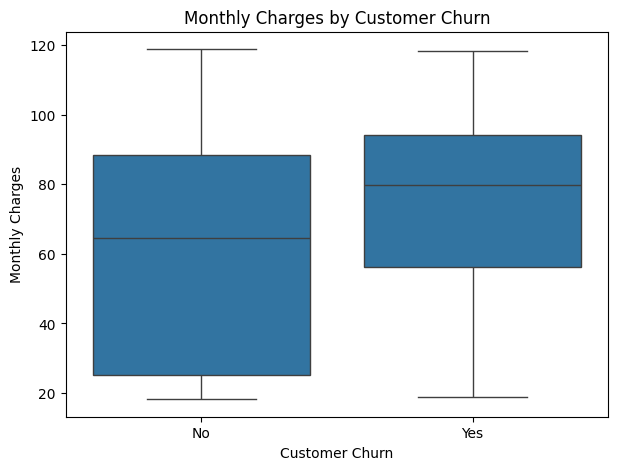

In [28]:
# Visualization 1: Monthly Charges by Churn

plt.figure(figsize=(7, 5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges by Customer Churn")
plt.xlabel("Customer Churn")
plt.ylabel("Monthly Charges")

plt.show()

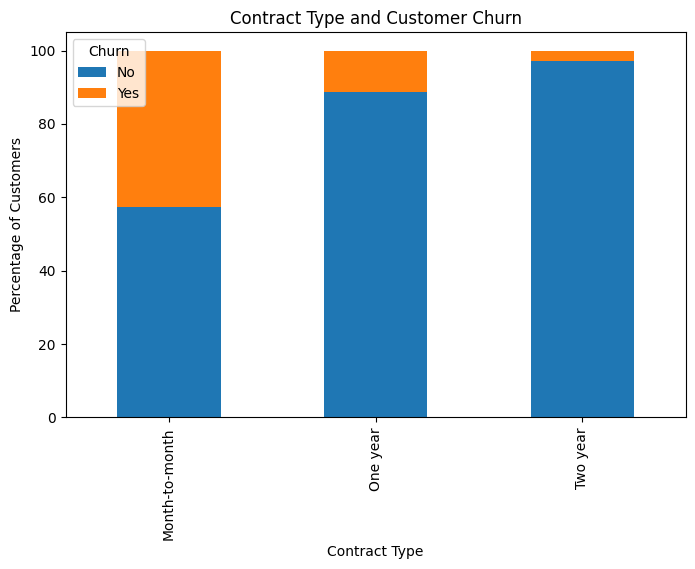

In [29]:
# Visualization 2: Contract Type vs Churn

contract_churn_table = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn_table.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Contract Type and Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.legend(title="Churn")

plt.show()

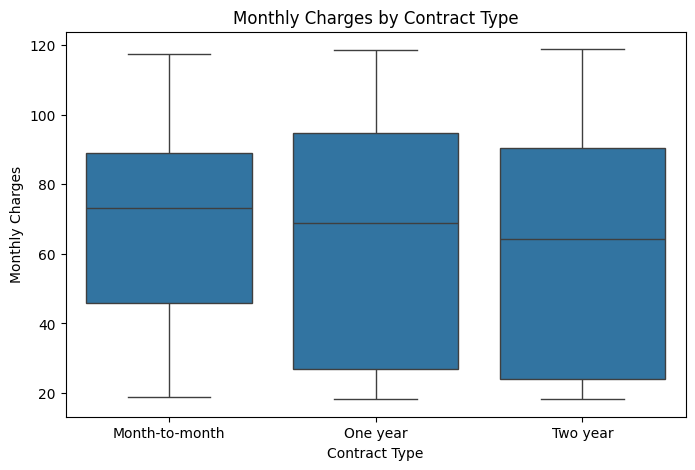

In [30]:
# Visualization 3: Monthly Charges by Contract Type

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Contract",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Monthly Charges")

plt.show()

In [31]:
# Confidence Interval for the Difference in Mean Monthly Charges

from scipy.stats import t

# Difference between the two group means
mean_difference = (
    monthly_charges_churned.mean()
    - monthly_charges_stayed.mean()
)

# Sample sizes
n_stayed = len(monthly_charges_stayed)
n_churned = len(monthly_charges_churned)

# Sample standard deviations
std_stayed = monthly_charges_stayed.std()
std_churned = monthly_charges_churned.std()

# Standard error of the difference
standard_error = np.sqrt(
    (std_stayed**2 / n_stayed) +
    (std_churned**2 / n_churned)
)

# Degrees of freedom for Welch's t-test
degrees_freedom = (
    (std_stayed**2 / n_stayed + std_churned**2 / n_churned)**2
    /
    (
        ((std_stayed**2 / n_stayed)**2 / (n_stayed - 1))
        +
        ((std_churned**2 / n_churned)**2 / (n_churned - 1))
    )
)

# 95% confidence interval
confidence_level = 0.95
alpha = 1 - confidence_level

critical_value = t.ppf(
    1 - alpha / 2,
    degrees_freedom
)

margin_of_error = critical_value * standard_error

lower_bound = mean_difference - margin_of_error
upper_bound = mean_difference + margin_of_error

print("Difference in mean MonthlyCharges:", mean_difference)
print("95% Confidence Interval:")
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Difference in mean MonthlyCharges: 13.176208567842295
95% Confidence Interval:
Lower bound: 11.772844895928612
Upper bound: 14.579572239755977


### Confidence Interval Interpretation

The difference in mean MonthlyCharges between churned and non-churned customers is approximately 13.18. The 95% confidence interval ranges from 11.77 to 14.58.

Since the entire confidence interval is above zero, it provides strong evidence that churned customers have higher average monthly charges than customers who stayed. This result is consistent with the independent two-sample t-test, which produced an extremely small p-value.

The confidence interval provides not only evidence of a statistically significant difference but also an estimated range for the size of that difference.

#8. Supporting Visualizations

Statistical results are supported with visualizations to make the findings easier to understand. The following visualizations compare customer churn across important variables and provide a visual interpretation of the statistical results.

The visualizations focus on MonthlyCharges, Contract type, and Churn status. They help connect the numerical statistical results with observable patterns in the dataset.

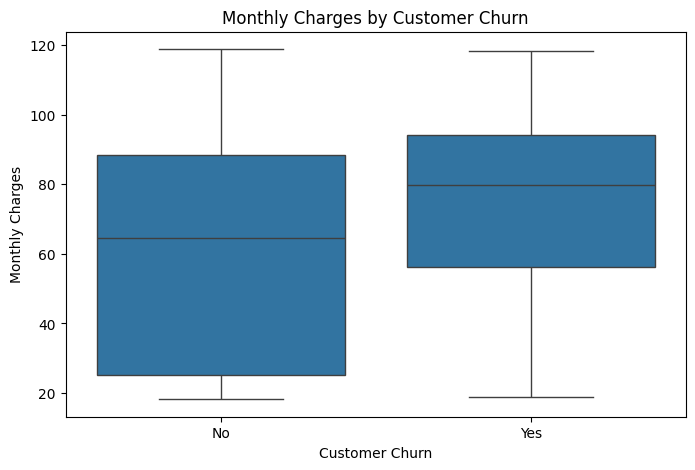

In [32]:
# Supporting Visualization 1: Monthly Charges by Customer Churn

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges by Customer Churn")
plt.xlabel("Customer Churn")
plt.ylabel("Monthly Charges")

plt.show()

### Visualization 1 — Monthly Charges by Customer Churn

The box plot shows the distribution of MonthlyCharges for customers who stayed and customers who churned. Churned customers have a higher median monthly charge, approximately 80, compared with approximately 65 for customers who stayed.

This visualization supports the independent two-sample t-test, which found a statistically significant difference in average MonthlyCharges between the two groups.

The result suggests that monthly charges are associated with customer churn. However, this association does not prove that higher charges directly cause customers to leave.

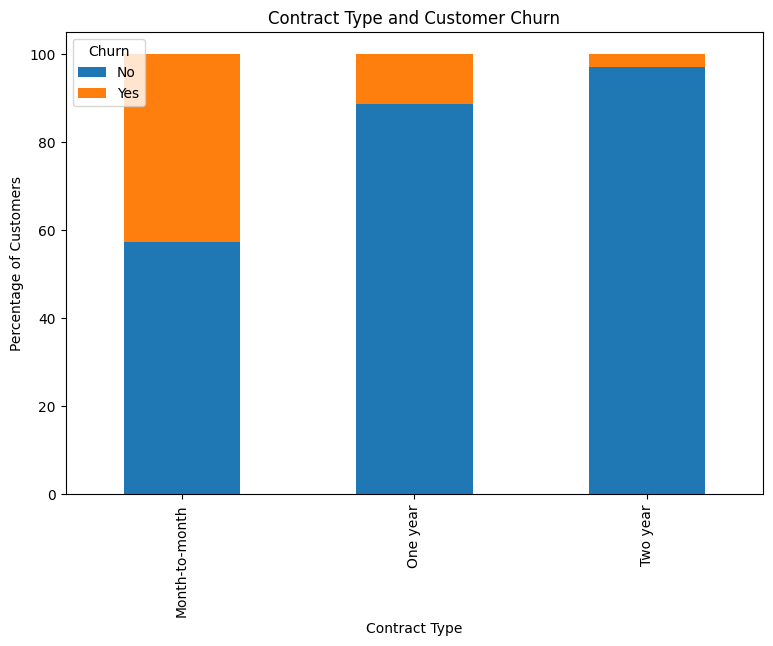

In [33]:
# Supporting Visualization 2: Contract Type and Customer Churn

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6)
)

plt.title("Contract Type and Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.legend(title="Churn")

plt.show()

### Visualization 2 — Contract Type and Customer Churn

The stacked bar chart shows a clear difference in customer churn across contract types. Month-to-month customers have the highest proportion of churned customers, while one-year and two-year contract customers have much lower churn proportions.

This visual pattern supports the Chi-square test of independence, which found a statistically significant association between Contract type and Churn.

The result suggests that contract type is an important factor associated with customer retention. However, the statistical association does not mean that contract type alone causes customers to churn.

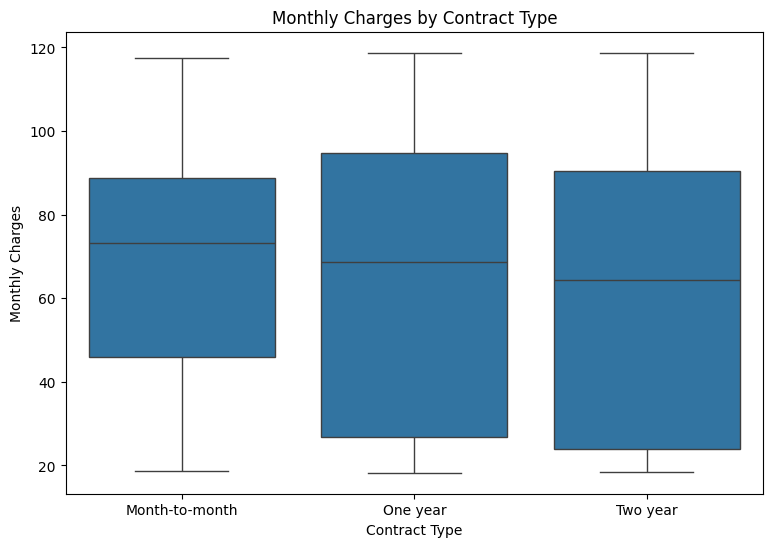

In [34]:
# Supporting Visualization 3: Monthly Charges by Contract Type

plt.figure(figsize=(9, 6))

sns.boxplot(
    x="Contract",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Monthly Charges")

plt.show()

### Visualization 3 — Monthly Charges by Contract Type

The box plot compares the distribution of MonthlyCharges across the three contract types. The median monthly charges differ across the groups, with month-to-month customers showing the highest median, followed by one-year and two-year customers.

This visualization supports the one-way ANOVA test, which found a statistically significant difference in average MonthlyCharges across the contract groups.

The result indicates that monthly charges are not distributed identically across the different contract types. However, ANOVA only confirms that at least one group differs; it does not identify which specific groups are significantly different.

## 9. Overall Statistical Findings

The statistical analysis examined three important relationships in the customer churn dataset using an independent two-sample t-test, Chi-square test of independence, and one-way ANOVA.

The t-test found a statistically significant difference in average MonthlyCharges between customers who stayed and customers who churned. The average monthly charge was approximately 61.27 for customers who stayed and 74.44 for customers who churned. The p-value was extremely small (8.59 × 10⁻⁷³), leading to rejection of the null hypothesis.

The Chi-square test found a statistically significant association between Contract type and Churn. The p-value was extremely small (5.86 × 10⁻²⁵⁸), indicating that churn status is not independent of contract type.

The ANOVA test also found a statistically significant difference in average MonthlyCharges across the three contract types. The F-statistic was approximately 20.83 and the p-value was 9.58 × 10⁻¹⁰, which is below the 0.05 significance level.

Overall, all three statistical tests provide strong evidence that the examined customer characteristics are associated with differences in customer churn or customer charges. These results strengthen the findings from the earlier exploratory and visualization analysis.

## 10. Business Implications

The statistical findings provide useful insights for customer retention strategies.

First, churned customers have significantly higher average MonthlyCharges than customers who stayed. This suggests that pricing, perceived value, or the combination of services and charges may be important factors to investigate.

Second, the Chi-square test shows a strong relationship between Contract type and Churn. Customers on different contract types have substantially different churn patterns. Therefore, encouraging customers to move from short-term contracts to longer-term contracts may help improve retention.

Third, the ANOVA result confirms that average MonthlyCharges differ across contract types. This indicates that contract structure and customer billing are related and should be considered together when designing retention strategies.

Based on these findings, the company should focus on identifying customers with higher charges and short-term contracts, particularly during the early stages of their relationship. Personalized offers, improved onboarding, proactive customer support, and incentives for longer-term contracts could help reduce churn.

However, statistical association does not prove that one factor directly causes churn. Further analysis and machine-learning models can be used to identify individual customers who are most likely to churn.

## 11. Conclusion

This week's analysis applied statistical analysis and hypothesis testing to the customer churn dataset. Three statistical tests were performed: an independent two-sample t-test, a Chi-square test of independence, and a one-way ANOVA.

The t-test showed a statistically significant difference in average MonthlyCharges between customers who stayed and customers who churned. The Chi-square test showed a statistically significant association between Contract type and Churn. The ANOVA test also showed that average MonthlyCharges differ significantly across the three contract types.

The confidence interval further supported the t-test result by showing that the difference in average MonthlyCharges is estimated to be between approximately 11.77 and 14.58.

Overall, the results show that customer churn is associated with important customer and billing characteristics. These findings can help the company identify high-risk customer segments and develop more targeted retention strategies.

This statistical analysis also provides a strong foundation for the next stage of the project, where machine-learning techniques can be used to predict the probability of churn for individual customers.